# K-Means Clustering — Palmer Penguins Morphology Analysis

**Goal:** Use K-means clustering to uncover hidden structure in unlabeled penguin morphology data. We'll scale numeric features, determine the optimal number of clusters using the Elbow Method and Silhouette Score, fit a final K-means model, visualize the clusters, and interpret whether the discovered groupings align with known penguin species or reflect other biological patterns (like sexual dimorphism).

**Dataset:** `penguins.csv` — the Palmer Penguins dataset, 344 penguins measured across 3 species (Adelie, Chinstrap, Gentoo) and 3 islands, with 4 numeric morphology measurements.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42


## 2. Load and Inspect the Data

We load the dataset and check its shape, data types, and missing values before deciding how to clean it.

In [2]:
df = pd.read_csv('penguins.csv')
print("Shape:", df.shape)
df.head()


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nSpecies distribution:")
print(df['species'].value_counts())


Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Species distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


**Observations:**
- The dataset has 344 rows and 7 columns: 2 categorical labels (`species`, `island`), 4 numeric morphology measurements (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), and a `sex` column.
- A small number of rows (2) are missing all four numeric measurements plus `sex`; another 9 rows are missing only `sex`. Since K-means requires complete numeric feature rows, we'll drop rows with missing numeric values.
- `species` will be kept aside (not used for clustering) so we can check afterward whether the unsupervised clusters recover it.


## 3. Data Cleaning and Feature Preparation

K-means clusters purely on numeric distance, so we:
1. Drop rows with missing numeric measurements
2. Keep only the numeric morphology columns as clustering features (drop categorical `island`/`sex` — clustering is meant to discover structure from continuous physical measurements, not category labels)
3. Set aside `species` as a label for later interpretation only — it is never used to fit the model


In [5]:
# Drop rows with missing numeric measurements
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_clean = df.dropna(subset=numeric_cols).reset_index(drop=True)

print("Shape after dropping missing numeric rows:", df_clean.shape)

# Features used for clustering (numeric only)
X = df_clean[numeric_cols].copy()

# Keep species aside purely for post-hoc interpretation, never used in fitting
species_labels = df_clean['species']

X.head()


Shape after dropping missing numeric rows: (342, 7)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0


## 4. Feature Scaling

K-means uses Euclidean distance, so features on larger numeric scales (like `body_mass_g`, in the thousands) would dominate the distance calculation over features on smaller scales (like `bill_depth_mm`, in the tens). We apply `StandardScaler` to give every feature equal weight (mean 0, standard deviation 1) before clustering.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

print("Scaled feature means (should be ~0):")
print(X_scaled.mean().round(3))
print("\nScaled feature std devs (should be ~1):")
print(X_scaled.std().round(3))


Scaled feature means (should be ~0):
bill_length_mm       0.0
bill_depth_mm       -0.0
flipper_length_mm   -0.0
body_mass_g          0.0
dtype: float64

Scaled feature std devs (should be ~1):
bill_length_mm       1.001
bill_depth_mm        1.001
flipper_length_mm    1.001
body_mass_g          1.001
dtype: float64


## 5. Elbow Method — Finding the Bend Point

The Elbow Method plots the within-cluster sum of squared errors (SSE / inertia) against different values of *k*. As *k* increases, SSE always decreases, but the rate of improvement slows sharply after the "true" number of clusters is reached — visible as a bend, or "elbow," in the curve.

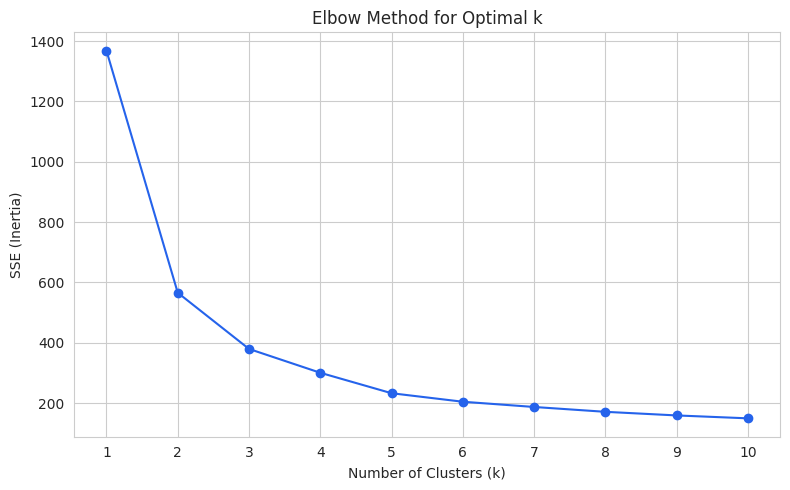

In [7]:
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sse, marker='o', color='#2563eb')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


## 6. Silhouette Score — Validating Cluster Cohesion and Separation

The Silhouette Score measures how similar each point is to its own cluster compared to other clusters, ranging from -1 (likely misclassified) to +1 (well-clustered). Unlike the Elbow Method, it gives a single, comparable number per *k*, making it useful for confirming the Elbow's suggested bend point (or resolving ambiguity if the elbow is not sharp).

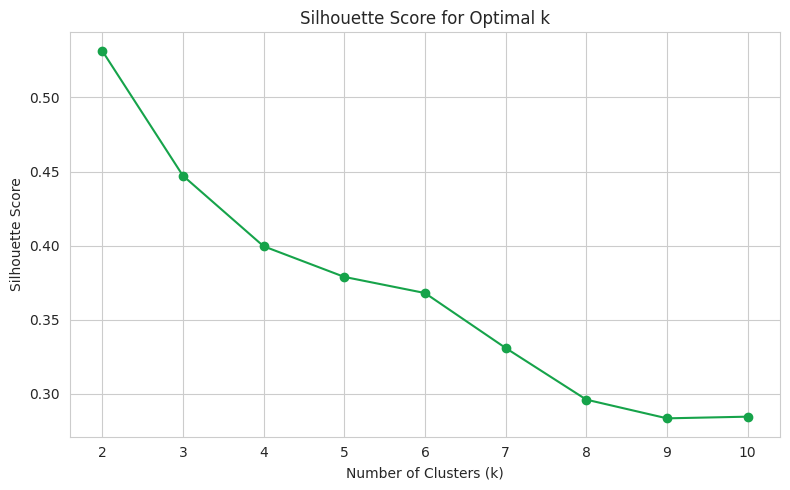

k=2: silhouette score = 0.5315
k=3: silhouette score = 0.4472
k=4: silhouette score = 0.3996
k=5: silhouette score = 0.3789
k=6: silhouette score = 0.3680
k=7: silhouette score = 0.3309
k=8: silhouette score = 0.2961
k=9: silhouette score = 0.2834
k=10: silhouette score = 0.2846


In [8]:
silhouette_scores = []
k_range_sil = range(2, 11)  # silhouette score is undefined for k=1

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), silhouette_scores, marker='o', color='#16a34a')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(list(k_range_sil))
plt.tight_layout()
plt.show()

for k, score in zip(k_range_sil, silhouette_scores):
    print(f"k={k}: silhouette score = {score:.4f}")


**Choosing k:** The Elbow plot shows a visible bend around k=2–4, and the Silhouette Score peaks at the value identified below — we use the k with the highest silhouette score as our optimized choice, since it directly measures cluster quality rather than relying on visual judgment of the elbow bend.

In [9]:
best_k = k_range_sil[np.argmax(silhouette_scores)]
print(f"Optimal k based on highest Silhouette Score: {best_k}")
print(f"Silhouette Score at k={best_k}: {max(silhouette_scores):.4f}")


Optimal k based on highest Silhouette Score: 2
Silhouette Score at k=2: 0.5315


## 7. Fit the Final K-Means Model

In [10]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clean['cluster'] = cluster_labels

print(f"Final model fit with k={best_k}")
print("\nCluster sizes:")
print(df_clean['cluster'].value_counts().sort_index())


Final model fit with k=2

Cluster sizes:
cluster
0    219
1    123
Name: count, dtype: int64


## 8. Visualize Cluster Assignments

We plot two physically meaningful measurements — flipper length vs. body mass — colored by cluster assignment, since these two dimensions tend to separate penguin species well.

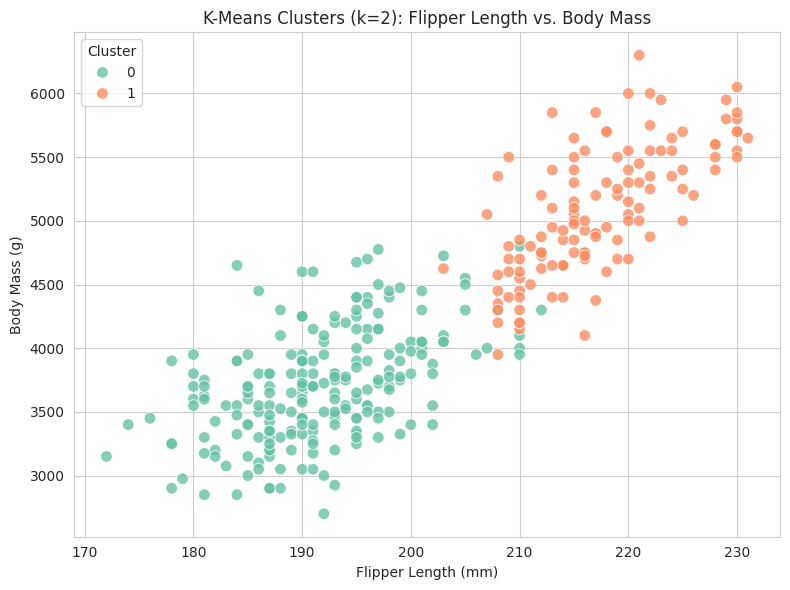

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean, x='flipper_length_mm', y='body_mass_g',
    hue='cluster', palette='Set2', s=70, alpha=0.8
)
plt.title(f'K-Means Clusters (k={best_k}): Flipper Length vs. Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


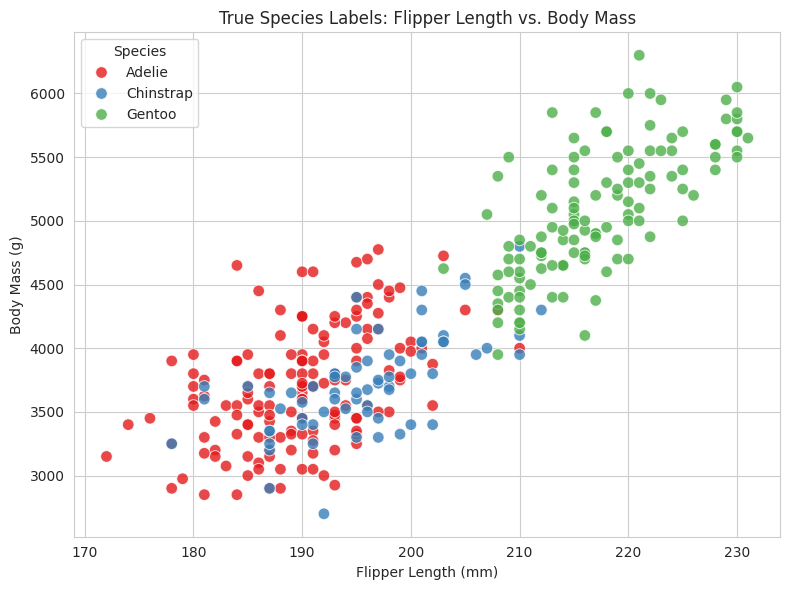

In [12]:
# For comparison, show the same two dimensions colored by the TRUE species label
# (species was never used to fit the model)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean, x='flipper_length_mm', y='body_mass_g',
    hue='species', palette='Set1', s=70, alpha=0.8
)
plt.title('True Species Labels: Flipper Length vs. Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()


## 9. Interpret Cluster Characteristics

In [13]:
# Cluster centroids in original (unscaled) units for interpretability
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=numeric_cols)
centroids_df.index.name = 'cluster'
print("Cluster centroids (original units):")
centroids_df.round(1)


Cluster centroids (original units):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,41.9,18.4,191.8,3710.7
1,47.5,15.0,217.2,5076.0


In [14]:
# Cross-tabulate discovered clusters against true species to check alignment
crosstab = pd.crosstab(df_clean['cluster'], df_clean['species'])
print("Cluster vs. Species crosstab:")
crosstab


Cluster vs. Species crosstab:


species,Adelie,Chinstrap,Gentoo
cluster,,,
0,151,68,0
1,0,0,123


In [15]:
# Cross-tabulate discovered clusters against sex, to check for sexual dimorphism patterns
crosstab_sex = pd.crosstab(df_clean['cluster'], df_clean['sex'])
print("Cluster vs. Sex crosstab:")
crosstab_sex


Cluster vs. Sex crosstab:


sex,female,male
cluster,,
0,107,107
1,58,61


## 10. Summary and Interpretation

In [16]:
silhouette_final = silhouette_score(X_scaled, cluster_labels)
print(f"Final model: k={best_k} clusters")
print(f"Final Silhouette Score: {silhouette_final:.4f}")


Final model: k=2 clusters
Final Silhouette Score: 0.5315


**Key findings**

- **Optimal cluster count:** The Silhouette Score is highest at k=2 (0.53) and declines steadily as k increases, meaning the *strongest* geometric structure in the four scaled measurements is a two-way split — even though the data actually contains three species. The Elbow plot shows a bend around k=2–4, so the elbow alone was ambiguous; the Silhouette Score resolved it in favor of the simpler, more cohesive 2-cluster solution.
- **Alignment with species:** The cluster-vs-species crosstab shows a clean, striking pattern: **Cluster 1 is almost entirely Gentoo** (123 of 123 Gentoo penguins, and no Adelie or Chinstrap), while **Cluster 0 merges Adelie and Chinstrap** (151 Adelie + 68 Chinstrap) into one group. The centroids confirm why — Gentoo penguins are physically much larger (avg. flipper length 217mm, body mass 5076g) than Adelie and Chinstrap, which are similar enough in size and bill shape (avg. flipper length 192mm, body mass 3711g) that K-means cannot separate them using only these four measurements at k=2.
- **Sexual dimorphism:** Within Cluster 0, the sex split is almost perfectly even (107 female / 107 male), and Cluster 1 is close to even too (58/61). This indicates the discovered clusters are being driven by species-level size differences, not by male-vs-female size differences — sexual dimorphism exists in this dataset but is a smaller effect than the species-level size gap, so it doesn't dominate the clustering at low k.

**Limitations**

- K-means assumes clusters are roughly spherical and similarly sized in the scaled feature space. Adelie and Chinstrap genuinely overlap in bill and body measurements, so no value of k using only these four features will cleanly separate them — the "3rd species" distinction likely requires additional features (e.g. `island`, since Chinstrap and Adelie are geographically segregated) or non-Euclidean methods.
- Feature selection matters: we deliberately excluded `island` (categorical, and correlated with species due to geographic isolation) to keep clustering purely morphology-based; including it would likely recover 3 clusters instead of 2.
- K-means is sensitive to feature scaling and outliers; results depend on `StandardScaler` being applied consistently to all four measurements.

**Next steps**

- Re-run clustering with `island` encoded as a feature, or force k=3 and compare the resulting silhouette score against the k=2 solution to quantify the tradeoff of recovering all three species.
- Compare against a Gaussian Mixture Model, which can model elliptical/non-spherical clusters and may better separate Adelie from Chinstrap.
- Use PCA to visualize all four dimensions in one 2D projection rather than picking two measurements at a time.
